# Stage 3 – EDA, Step 7: The Train / Test Split

**Project:** Machine Learning-Based U.S. Residential Rental Price Estimation System
**Continues from:** `05_eda_outliers.ipynb` (Step 6)

---

## Where we are

Steps 1–6 were the **data-quality phase**. Every cleaning rule has been decided with evidence and written once in `clean_data()` (`src/cleaning.py`). This notebook does three things:

1. **Builds the final clean dataset** by running `clean_data()` with every rule.
2. **Splits it** into a **training set (80%)** and a **test set (20%)**.
3. **Checks the split**: that both sets look alike, and that nothing links them.

After this notebook, the plan in notebook 01 changes gear. From Step 8 onward, every chart, every relationship analysis, and every model decision uses the **training set only**.

---

## Background: why we split, and why so carefully

**The test set is the final exam.** A model is useful only if it predicts rents for listings it has **never seen**. The test set stands in for those future listings. We lock it away now, before we study any relationships with price, and open it **once**, at the very end, to measure the final model.

**Why lock it away *before* the relationship analysis (Steps 8–12)?** Suppose we plotted rent against size using *all* the data, noticed a pattern, and designed a feature around it. The test set would then have influenced the model's design, and its score would be slightly optimistic, because the test set would no longer be truly unseen. This is called **data snooping**. Splitting first prevents it.

**Why 80/20?** With about 188,000 listings, 20% gives a test set of roughly 37,000. That's large enough for a very precise estimate of the error, while leaving about 150,000 listings for training.

**Why no separate "validation" set?** Choosing between the five models and tuning their settings also needs unseen data. We'll use **cross-validation on the training set**: train on 4/5 of it, check on the remaining 1/5, and rotate five times. Every training listing gets used for both training and checking, which is more reliable than one fixed validation set, and the test set stays untouched.

**Two requirements for a good split, and how we meet them:**

1. **Both sets must look alike** (the same mix of cheap and expensive rentals). Otherwise the test score reflects luck in the split rather than the model's quality. Solution: **stratify** on price bands (7.3).
2. **Nothing may link the two sets.** If copies or close relatives of a listing sit on both sides, the model has effectively seen part of the exam. Step 4 removed exact copies. 7.4 deals with the close relatives that remain.

## 7.0 Setup

The usual imports and shared helpers. Three new tools appear:

- **`StratifiedGroupKFold`** (scikit-learn) makes a split that is both **stratified** (balanced price bands) and **grouped** (related listings stay together). Section 7.5 explains it.
- **`connected_components`** (SciPy) finds "families" of related listings (7.4).
- **`ks_2samp`** (SciPy) is a statistical test comparing the two price distributions (7.6).

In [1]:
# 7.0 Setup

%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets Python find the src/ folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from scipy.stats import ks_2samp
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

from src.utils import *
from src.cleaning import clean_data
setup_display()
warnings.filterwarnings("ignore", category=FutureWarning)

show_obs(6)   # Step 6 findings, to confirm the handover

,step,observation,evidence,decision
0,6-Outliers,IQR rule flags 4.9% of prices and 5.1% of size...,"6.1 IQR table, 6.2 log-scale box plots",Most raw-scale 'outliers' are the natural righ...
1,6-Outliers,IQR fences for discrete counts are misleading:...,6.1 IQR table,No IQR-based removal for beds/baths; Step 5 li...
2,6-Outliers,The top 5 states hold 75% of nationally-high r...,"6.4 national vs within-state fences, examples",High rents are mostly genuine expensive market...
3,6-Outliers,Price per sq ft outside $0.25-$10: 535 listing...,"6.5 quantiles, threshold counts, examples","Remove (fixed domain rule, no leakage): room, ..."
4,6-Outliers,"Non-home property types ['land', 'assisted liv...",6.6 type table and examples,Remove (not residential homes); rare genuine t...
5,6-Outliers,price: skew 2.73 raw vs 0.37 after log1p,6.7 skewness table,Keep genuine extremes; log transform is enough...
6,6-Outliers,sqfeet: skew 3.27 raw vs 0.20 after log1p,6.7 skewness table,Keep genuine extremes; log transform is enough...
7,6-Outliers,beds skew 0.57 raw vs -0.58 after log1p; baths...,6.7 skewness table,No log transform for beds/baths (small counts;...
8,6-Outliers,"Step 6 rules would remove 540 of 188,546 clean...",6.8 combined effect,Rules confirmed and added to clean_data() in s...


## 7.1 The final clean dataset

**What this cell does:** it runs `clean_data()` on the raw data with **every** rule from Steps 2–6, shows the funnel (how many rows each stage removes), and saves the result as `data/processed/housing_clean.parquet`.

**The stages, in the order decided in Step 4:**

| Stage | Rule | Decided in |
|---|---|---|
| Price | keep \$250 – \$10,000 | Steps 2 and 5.9 |
| Size, beds, baths | 100–10,000 sq ft; 0–8 beds; 0.5–8 baths; at least 70 sq ft per room; baths ≤ beds + 3 | Steps 5.1–5.4 |
| Location | blank pins outside the U.S.; remove pins more than 500 km from their region | Steps 5.5–5.6 |
| Price per sq ft and type | keep \$0.25–\$10 per sq ft; remove land and assisted living | Step 6 |
| State | one label per Craigslist site | Step 5.7 |
| Deduplication | one row per group of identical features + price | Step 4 |

**Why the rules can run before the split:** each rule uses a **fixed limit** chosen from domain knowledge and evidence (like "\$250 to \$10,000"), not a statistic learned from the data. So applying them to all rows doesn't pass any information from the future test set into the model. The one exception to watch is the region centres used for the 500 km check, which are computed from the data. But they use only **coordinates**, never prices, so they can't leak anything about the target.

In [2]:
# 7.1 Run every cleaning rule and save the final clean dataset

dc, funnel = clean_data(load_raw())
display(funnel.style.format({"rows": "{:,}", "removed": "{:,}", "%_of_raw_remaining": "{:.1f}%"}))

dc.to_parquet(CLEAN_FILE, index=False)
print(f"Saved {len(dc):,} rows to {CLEAN_FILE.relative_to(ROOT)}")

clean_data: 384,977 -> 188,006 rows (48.8% kept); 260 pins outside the U.S. blanked


,rows,removed,%_of_raw_remaining
stage,,,
1. Raw data,"384,977",0,100.0%
"2. Price $250-$10,000 (Steps 2, 5.9)","381,800","3,177",99.2%
"3. Valid size, beds, baths (Steps 5.1-5.4)","377,572","4,228",98.1%
4. Location consistent (Steps 5.5-5.6),"376,776",796,97.9%
"5. Price per sq ft $0.25-$10, homes only (Step 6)","376,046",730,97.7%
6. Deduplicated (Step 4),"188,006","188,040",48.8%


Saved 188,006 rows to data\processed\housing_clean.parquet


## 7.2 Price bands for stratification

**What this cell does:** it splits the listings into **10 equal-sized price bands (deciles)** using `log(1 + price)`, as planned in Step 2.8, and shows the dollar range of each band.

**Why:** a purely random split *usually* gives both sets a similar mix of prices, but not always. By chance, the test set could get slightly more expensive listings, making the model look worse (or better) than it really is. **Stratifying** means splitting *within* each band: 80% of band 1 goes to training and 20% to test, then the same for band 2, and so on. Both sets then have exactly the same share of every price band.

**Why log price?** On the log scale the bands are more evenly spread across the whole range. On the raw scale, the top band would stretch from about \$1,900 to \$10,000 while the bottom bands would be only a few dollars wide.

**Is it leakage to use price here?** No. The bands only decide *which side* of the split each listing lands on, so that both sides are balanced. No information about any price is given to the model, and the bands aren't used as a feature. This is standard practice.

In [3]:
# 7.2 Log-price deciles

log_price = np.log1p(dc["price"])
price_band = pd.qcut(log_price, q=10, labels=False, duplicates="drop")

band_table = (dc.assign(band=price_band + 1)
                .groupby("band")["price"].agg(listings="size", from_="min", to="max"))
band_table.columns = ["listings", "from_$", "to_$"]
band_table.style.format({"listings": "{:,}", "from_$": "${:,.0f}", "to_$": "${:,.0f}"})

,listings,from_$,to_$
band,,,
1,"19,302",$250,$695
2,"18,507",$696,$815
3,"18,610",$816,$918
4,"19,073",$919,"$1,015"
5,"19,465","$1,016","$1,150"
6,"17,939","$1,151","$1,280"
7,"18,729","$1,281","$1,442"
8,"18,835","$1,443","$1,650"
9,"18,745","$1,651","$2,076"


## 7.3 Close relatives: the duplicates Step 4 couldn't catch

Step 4 removed listings that were identical in **every model feature and the price**. But two kinds of close relatives can survive that rule:

1. **Same listing, new price.** A landlord reposts the same apartment, but at \$840 instead of \$835 (Step 5.5 showed exactly this for Harbin Pointe in Fayetteville). Every feature is identical; only the price differs by a few dollars. Step 4 kept both, because the prices differ.
2. **Same text, a small edit.** A landlord reposts with the same description in the same region, but changes a detail, such as a pet flag or the parking option. Step 4 kept both, because one feature differs. (Step 4.1's "level 3" counted this type.)

**Why they matter for the split:** if one relative lands in training and the other in test, the model is asked to predict a listing whose near-twin it has already seen, with an almost identical answer. That's a milder version of the leakage Step 4 measured (58.9% of test rows before deduplication), and it makes the test score optimistic in the same way.

**What this cell does:** it links every listing to its relatives through two shared keys:

- **feature key:** exactly the same values for every model feature (price ignored);
- **text key:** the same description in the same Craigslist site (only descriptions of at least 50 characters, so short generic texts like "2 bedroom" don't link unrelated listings).

Relationships chain together: if A shares a feature key with B, and B shares a description with C, then A, B and C are one **family**. Finding these chains is a classic graph problem called **connected components**. Each listing is a point, each shared key is a line between points, and a component is a group of points connected by lines. SciPy's `connected_components` finds them all in a second or two.

**How to read the output:** the number of families, how many listings belong to a family of 2 or more, and the size of the largest family. If one family were enormous (say over 5% of all listings), a grouped split couldn't balance it, but that's very unlikely.

In [4]:
# 7.3 Find families of related listings

n = len(dc)
feature_key = dc.groupby(MODEL_FEATURES, dropna=False).ngroup().to_numpy()

desc = dc["description"].fillna("")
long_desc = desc.str.len() >= 50
text_key = pd.Series(-1, index=dc.index)
text_key[long_desc] = dc[long_desc].groupby([desc[long_desc], dc.loc[long_desc, "region_url"]]).ngroup()
text_key = text_key.to_numpy()

# Graph: listing nodes 0..n-1, feature-key nodes, text-key nodes; an edge joins a listing to each of its keys
n_feat = feature_key.max() + 1
rows = np.concatenate([np.arange(n), np.flatnonzero(text_key >= 0)])
cols = np.concatenate([n + feature_key, n + n_feat + text_key[text_key >= 0]])
size = n + n_feat + (text_key.max() + 1)
graph = sparse.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(size, size))
_, component = connected_components(graph, directed=False)

dc["group_id"] = pd.Series(component[:n]).factorize()[0]
family_size = dc["group_id"].map(dc["group_id"].value_counts())

print(f"Listings:                          {n:,}")
print(f"Families (groups):                 {dc['group_id'].nunique():,}")
print(f"Listings with at least 1 relative: {(family_size > 1).sum():,} ({(family_size > 1).mean() * 100:.1f}%)")
print(f"Largest family:                    {family_size.max():,} listings ({family_size.max() / n * 100:.2f}% of all)")

print("\nFamily sizes:")
display(dc["group_id"].value_counts().value_counts().sort_index().rename("families")
          .rename_axis("listings in family").to_frame().T)

Listings:                          188,006
Families (groups):                 137,641
Listings with at least 1 relative: 69,841 (37.1%)
Largest family:                    113 listings (0.06% of all)

Family sizes:


listings in family,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,41,42,44,45,46,49,50,51,52,54,55,57,58,61,62,63,64,65,66,81,86,88,92,94,113
families,118165,10863,3551,1751,946,613,419,265,209,152,124,87,64,58,50,39,30,25,29,24,18,12,8,3,15,...,3,3,6,2,1,2,1,1,1,2,4,1,1,1,2,1,1,1,1,2,1,1,1,1,1


### 7.3 (cont.) What a family looks like

**What this cell does:** it shows the listings in one of the larger families, so you can see *why* they were linked: the same features at slightly different prices, or the same text with a small edit.

**Why:** as in every earlier step, one real example makes the idea concrete, and it's the kind of evidence worth putting in the report.

In [5]:
# 7.3 (cont.) Example family

sizes = dc["group_id"].value_counts()
example_id = sizes[sizes.between(4, 12)].index[0] if (sizes.between(4, 12)).any() else sizes.index[0]
example = dc.loc[dc["group_id"] == example_id,
                 ["price", "type", "sqfeet", "beds", "baths", "laundry_options", "parking_options",
                  "region", "description"]].head(8).copy()
example["description"] = example["description"].str.slice(0, 70)
with pd.option_context("display.max_colwidth", 80):
    display(example)

,price,type,sqfeet,beds,baths,laundry_options,parking_options,region,description
106,1460,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Bedrooms: 2 Bathrooms: 2 Square Feet: 1167 Seize your chance to live
209,1468,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Seize your chance to live in one of the premier apartment communities
475,1513,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Seize your chance to live in one of the premier apartment communities
535,1496,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Bedrooms: 2 Bathrooms: 2 Square Feet: 1167 Seize your chance to live
540,1488,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Bedrooms: 2 Bathrooms: 2 Square Feet: 1167 Seize your chance to live
563,1441,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,2BD | 2BA | 1167SQFTSeize your chance to live in one of the premier ap
592,1516,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,Bedrooms: 2 Bathrooms: 2 Square Feet: 1167 Seize your chance to live
96390,1522,apartment,1167,2,2.00,NaN,NaN,reno / tahoe,2BD | 2BA | 1167SQFTSeize your chance to live in one of the premier ap


## 7.4 How much would relatives leak in a normal split?

**What this cell does:** before choosing the split method, it measures the problem. It makes an ordinary **random stratified split** (80/20, the same seed) and counts the **test listings that have a relative in the training set**. It then does the same with a **grouped** split, where every family is kept together on one side.

**How to read the output:** the random split's percentage is the share of the "final exam" whose near-twin the model would already have studied. The grouped split should bring this to **0%** by design. If the random split's figure is only a fraction of a percent, the grouped split changes little. If it's several percent or more, the grouped split is clearly necessary.

In [6]:
# 7.4 Relatives across a random split vs a grouped split

def test_rows_with_relative_in_train(train_idx, test_idx):
    train_groups = set(dc.loc[train_idx, "group_id"])
    return dc.loc[test_idx, "group_id"].isin(train_groups).mean() * 100

rand_train, rand_test = train_test_split(dc.index, test_size=0.2, stratify=price_band,
                                         random_state=RANDOM_STATE)
leak_random = test_rows_with_relative_in_train(rand_train, rand_test)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_pos, test_pos = next(sgkf.split(np.zeros(n), price_band, groups=dc["group_id"]))
train_idx, test_idx = dc.index[train_pos], dc.index[test_pos]
leak_grouped = test_rows_with_relative_in_train(train_idx, test_idx)

print(f"Test listings with a relative in training, random stratified split:  {leak_random:.2f}%")
print(f"Test listings with a relative in training, grouped stratified split: {leak_grouped:.2f}%")

Test listings with a relative in training, random stratified split:  34.72%
Test listings with a relative in training, grouped stratified split: 0.00%


## 7.5 The split: stratified *and* grouped

**How `StratifiedGroupKFold` works:** it divides the data into 5 equal "folds" (20% each), following two rules at once:

- **Grouped:** every family from 7.3 goes into exactly **one** fold, so relatives never end up on different sides.
- **Stratified:** it assigns the families to folds so that each fold's mix of price bands is as close as possible to the overall mix.

We take **one fold (20%) as the test set** and the other four (80%) as the training set. That's the split already computed in 7.4. With a fixed `random_state`, the same families land in the same fold every time, so every group member gets the identical split.

**Why the training set keeps a `group_id` column:** in the modelling stage, the cross-validation *inside* the training set must also keep families together, or the model-selection scores would leak in exactly the same way. `group_id` lets the modelling code use `GroupKFold`. It's an identifier only, never a feature. `MODEL_FEATURES` in `utils.py` doesn't include it.

**What this cell does:** it creates the two sets, reports their sizes, and checks that no family appears in both.

In [7]:
# 7.5 Create the training and test sets

train = dc.loc[train_idx].reset_index(drop=True)
test = dc.loc[test_idx].reset_index(drop=True)

print(f"Training set: {len(train):,} listings ({len(train) / n * 100:.1f}%)")
print(f"Test set:     {len(test):,} listings ({len(test) / n * 100:.1f}%)")
print(f"Families in both sets: {len(set(train['group_id']) & set(test['group_id']))}")

Training set: 150,404 listings (80.0%)
Test set:     37,602 listings (20.0%)
Families in both sets: 0


## 7.6 Do the two sets look alike?

A good split gives two sets that differ only by chance. **What this cell checks:**

1. **Price bands:** the share of listings in each of the 10 bands, for train and test. Stratification should make these almost identical.
2. **Price quantiles:** the 5th, 25th, 50th, 75th and 95th percentile rents in each set.
3. **The KS test** (Kolmogorov–Smirnov) compares the two whole price distributions. Its statistic **D** is the largest gap between the two sets' cumulative distributions: the share of listings below each price, compared across all prices. D = 0.01 means the two sets never differ by more than 1 percentage point at any price. As in Step 3, with tens of thousands of rows the **p-value** is very sensitive, so **D is the number to read**: anything around 0.01 or below is excellent.
4. **Things we did *not* stratify on:** property type, the top 10 states, and how often parking and laundry are missing. These should also match closely, just from the size of the sets. A big difference would signal a problem with the grouping.

**How to read the output:** the "max difference" column shows the largest gap in percentage points. Gaps below about 1 point mean the two sets are, for practical purposes, the same population.

In [8]:
# 7.6 Compare the training and test sets

def share_compare(col_train, col_test, name, top=None):
    a = col_train.value_counts(normalize=True) * 100
    b = col_test.value_counts(normalize=True) * 100
    t = pd.DataFrame({"train_%": a, "test_%": b}).fillna(0)
    if top:
        t = t.sort_values("train_%", ascending=False).head(top)
    t["difference"] = t["test_%"] - t["train_%"]
    print(f"{name}: max difference {t['difference'].abs().max():.2f} percentage points")
    return t

bands = share_compare(pd.qcut(np.log1p(train["price"]), 10, labels=False),
                      pd.cut(np.log1p(test["price"]),
                             bins=pd.qcut(np.log1p(train["price"]), 10, retbins=True)[1],
                             labels=False, include_lowest=True),
                      "Price bands (train deciles)")
types = share_compare(train["type"], test["type"], "Property type")
states = share_compare(train["state"], test["state"], "Top 10 states", top=10)

missing = pd.DataFrame({
    "train_%": [train["parking_options"].isna().mean() * 100, train["laundry_options"].isna().mean() * 100],
    "test_%": [test["parking_options"].isna().mean() * 100, test["laundry_options"].isna().mean() * 100],
}, index=["parking missing", "laundry missing"])
missing["difference"] = missing["test_%"] - missing["train_%"]

quantiles = pd.DataFrame({
    "train": train["price"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]),
    "test": test["price"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]),
}).rename(lambda q: f"{q * 100:g}%")

ks = ks_2samp(np.log1p(train["price"]), np.log1p(test["price"]))
print(f"KS test on log price: D = {ks.statistic:.4f} (p = {ks.pvalue:.3f})")

fmt = {"train_%": "{:.2f}%", "test_%": "{:.2f}%", "difference": "{:+.2f}"}
print("\nPrice quantiles (USD)"); display(quantiles.style.format("${:,.0f}"))
print("Property type"); display(types.style.format(fmt))
print("Top 10 states"); display(states.style.format(fmt))
print("Missing values"); display(missing.style.format(fmt))

Price bands (train deciles): max difference 0.00 percentage points
Property type: max difference 0.34 percentage points
Top 10 states: max difference 0.35 percentage points
KS test on log price: D = 0.0021 (p = 0.999)

Price quantiles (USD)


,train,test
5%,$600,$600
25%,$872,$872
50%,"$1,150","$1,150"
75%,"$1,539","$1,536"
95%,"$2,505","$2,530"


Property type


,train_%,test_%,difference
type,,,
apartment,74.43%,74.76%,+0.34
condo,2.69%,2.72%,+0.03
cottage/cabin,0.34%,0.27%,-0.07
duplex,2.10%,2.21%,+0.11
flat,0.25%,0.22%,-0.02
house,14.14%,14.03%,-0.11
in-law,0.09%,0.07%,-0.01
loft,0.24%,0.23%,-0.01
manufactured,1.34%,1.22%,-0.12


Top 10 states


,train_%,test_%,difference
state,,,
ca,10.10%,9.99%,-0.11
fl,7.71%,7.70%,-0.00
tx,7.34%,7.56%,+0.21
nc,4.21%,4.12%,-0.09
mi,3.86%,4.14%,+0.28
ny,3.46%,3.52%,+0.07
co,3.28%,3.28%,-0.01
oh,3.27%,3.14%,-0.13
or,2.82%,2.47%,-0.35


Missing values


,train_%,test_%,difference
parking missing,31.51%,31.18%,-0.34
laundry missing,18.08%,18.28%,+0.20


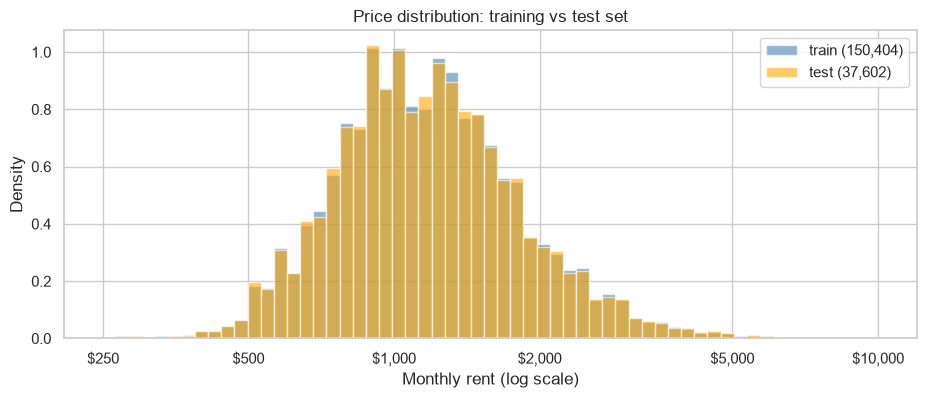

In [9]:
# 7.6 (cont.) Price distributions of the two sets

fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(np.log1p(RENT_FLOOR), np.log1p(PRICE_MAX), 60)
ax.hist(np.log1p(train["price"]), bins=bins, density=True, alpha=0.6, label=f"train ({len(train):,})", color="steelblue")
ax.hist(np.log1p(test["price"]), bins=bins, density=True, alpha=0.6, label=f"test ({len(test):,})", color="orange")
ticks = [250, 500, 1000, 2000, 5000, 10000]
ax.set_xticks(np.log1p(ticks))
ax.set_xticklabels([f"${t:,}" for t in ticks])
ax.set(xlabel="Monthly rent (log scale)", ylabel="Density", title="Price distribution: training vs test set")
ax.legend()
save_fig("07_train_test_price")
plt.show()

## 7.7 Final leakage checks

**What this cell does:** it runs four checks that must **all** pass before the test set is locked away:

| Check | What it would mean if it failed |
|---|---|
| No `id` in both sets | the same listing is in both sets |
| No identical features + price in both sets | a Step 4 duplicate survived |
| No identical features (any price) in both sets | a "same listing, new price" relative crossed the split |
| No shared long description + region in both sets | a "same text, small edit" relative crossed the split |

The first two should pass because of Step 4. The last two pass because of the grouped split.

In [10]:
# 7.7 Leakage checks between the training and test sets

def overlap(cols, frame_filter=None):
    key = lambda d: pd.util.hash_pandas_object(d[cols], index=False)
    tr, te = train, test
    if frame_filter is not None:
        tr, te = tr[frame_filter(tr)], te[frame_filter(te)]
    return int(key(te).isin(set(key(tr))).sum())

long_text = lambda d: d["description"].fillna("").str.len() >= 50
checks = {
    "same id": overlap(["id"]),
    "identical features + price": overlap(MODEL_FEATURES + [TARGET]),
    "identical features (any price)": overlap(MODEL_FEATURES),
    "same long description + region": overlap(["description", "region_url"], long_text),
}
leak_checks = pd.Series(checks, name="test listings affected").to_frame()
leak_checks["result"] = np.where(leak_checks["test listings affected"] == 0, "PASS", "FAIL")
display(leak_checks)

,test listings affected,result
same id,0,PASS
identical features + price,0,PASS
identical features (any price),0,PASS
same long description + region,0,PASS


## 7.8 Categories the training set has never seen

**What this cell does:** for each categorical feature (`region_url`, `state`, `type`, `laundry_options`, `parking_options`), it lists any value that appears in the **test** set but **never** in the training set.

**Why:** a model can only learn from categories it has seen. If a region appears only in the test set, the model meets it for the first time during the final evaluation, exactly as the deployed system would with a brand-new region. The preprocessing pipeline must handle this without crashing: one-hot encoding with `handle_unknown="ignore"`, and target encoding falling back to the overall average. This check tells us whether that situation actually occurs in our data, and how often.

**How to read the output:** ideally every list is empty. A few rare regions appearing only in the test set wouldn't be a problem, but they must be handled by the pipeline, and they're recorded in the log.

In [11]:
# 7.8 Values present in test but never seen in training

cat_cols = ["region_url", "state", "type", "laundry_options", "parking_options"]
unseen = {}
for col in cat_cols:
    new_values = sorted(set(test[col].dropna()) - set(train[col].dropna()))
    unseen[col] = new_values
    affected = int(test[col].isin(new_values).sum())
    print(f"{col:17s} {len(new_values)} unseen value(s), {affected} test listings"
          + (f": {new_values[:5]}" if new_values else ""))

region_url        0 unseen value(s), 0 test listings
state             0 unseen value(s), 0 test listings
type              0 unseen value(s), 0 test listings
laundry_options   0 unseen value(s), 0 test listings
parking_options   0 unseen value(s), 0 test listings


## 7.9 Save the two sets and lock the test set away

**What this cell does:** it saves `train.parquet` and `test.parquet` in `data/processed/`.

**From now on:**

- **Every notebook loads the training set with `load_train()`** (from `utils.py`).
- **The test set is opened only once**, with `load_test()`, at the very end of the modelling stage, to evaluate the single final model. `load_test()` carries a warning in its docstring as a reminder.
- If you ever need to re-split (for example, because a cleaning rule changed), re-run this whole notebook. The fixed seed makes the split reproducible, but any change to the cleaning changes which listings exist, so the split must be regenerated rather than patched.

A note for teamwork: the two files are in `data/`, so Git ignores them. Every teammate recreates them by running this notebook. Because the seed is fixed, everyone gets exactly the same split.

In [12]:
# 7.9 Save the training and test sets

train.to_parquet(TRAIN_FILE, index=False)
test.to_parquet(TEST_FILE, index=False)
print(f"Saved {len(train):,} rows to {TRAIN_FILE.relative_to(ROOT)}")
print(f"Saved {len(test):,} rows to {TEST_FILE.relative_to(ROOT)}")

Saved 150,404 rows to data\processed\train.parquet
Saved 37,602 rows to data\processed\test.parquet


## 7.10 Log the Step 7 observations

As before, `clear_obs("7")` removes older Step 7 entries, and the numbers are filled in from your results.

In [13]:
# 7.10 Log the observations

clear_obs("7")
stage_rows = funnel["rows"]

log_obs("7-Split",
        "Final clean dataset: " + " -> ".join(f"{v:,}" for v in stage_rows)
        + f" rows ({stage_rows.iloc[-1] / stage_rows.iloc[0] * 100:.1f}% of raw kept)",
        "7.1 clean_data() funnel",
        "All cleaning rules applied once, before the split; saved to data/processed/housing_clean.parquet")

log_obs("7-Split",
        f"{(family_size > 1).mean() * 100:.1f}% of clean listings have a close relative (same features at another "
        f"price, or same text with a small edit); largest family {family_size.max():,} listings",
        "7.3 connected components on feature and text keys",
        "Treat each family as one group when splitting and in cross-validation")

log_obs("7-Split",
        f"A random stratified split would put {leak_random:.2f}% of test listings next to a relative in training; "
        f"the grouped split: {leak_grouped:.2f}%",
        "7.4 simulated random vs grouped split",
        "Use StratifiedGroupKFold (stratified on log-price deciles, grouped by family); take one fold as the test set")

log_obs("7-Split",
        f"Training {len(train):,} ({len(train) / n * 100:.1f}%), test {len(test):,}; KS D = {ks.statistic:.4f}; "
        f"max share difference: bands {bands['difference'].abs().max():.2f}, types {types['difference'].abs().max():.2f}, "
        f"states {states['difference'].abs().max():.2f} percentage points",
        "7.5 sizes, 7.6 comparison tables and histogram",
        "The two sets are the same population; the test score will be a fair estimate")

log_obs("7-Split",
        f"Leakage checks: {', '.join(f'{k}: {v}' for k, v in checks.items())}",
        "7.7 overlap checks",
        "All must be 0 before locking the test set" + (" (all PASS)" if sum(checks.values()) == 0 else " (INVESTIGATE: a check failed)"))

n_unseen = {k: len(v) for k, v in unseen.items()}
log_obs("7-Split",
        f"Categories seen only in test: {n_unseen}",
        "7.8 unseen-category check",
        "Pipeline must handle unknown categories (one-hot handle_unknown='ignore'; target-encoding fallback to the mean)")

log_obs("7-Split",
        "Training set keeps group_id for grouped cross-validation; group_id is never a model feature",
        "7.5",
        "Model selection uses GroupKFold on the training set; the test set is opened once, for the final model")

show_obs(7)

,step,observation,evidence,decision
0,7-Split,"Final clean dataset: 384,977 -> 381,800 -> 377...",7.1 clean_data() funnel,"All cleaning rules applied once, before the sp..."
1,7-Split,37.1% of clean listings have a close relative ...,7.3 connected components on feature and text keys,Treat each family as one group when splitting ...
2,7-Split,A random stratified split would put 34.72% of ...,7.4 simulated random vs grouped split,Use StratifiedGroupKFold (stratified on log-pr...
3,7-Split,"Training 150,404 (80.0%), test 37,602; KS D = ...","7.5 sizes, 7.6 comparison tables and histogram",The two sets are the same population; the test...
4,7-Split,"Leakage checks: same id: 0, identical features...",7.7 overlap checks,All must be 0 before locking the test set (all...
5,7-Split,Categories seen only in test: {'region_url': 0...,7.8 unseen-category check,Pipeline must handle unknown categories (one-h...
6,7-Split,Training set keeps group_id for grouped cross-...,7.5,Model selection uses GroupKFold on the trainin...


---

## What's next: Step 8 – Univariate distributions (training set)

The data-quality phase and the split are complete. From here the EDA looks at the data to learn from it, using **only the training set** (`load_train()`):

- histograms of the numeric features (`sqfeet`, `beds`, `baths`, `lat`, `long`);
- bar charts of `type`, `laundry_options`, `parking_options` and the top 15 states;
- the share of "yes" for each of the six binary flags.

These reveal which features need transforming, which categories dominate, and which are rare enough to group.